# 04 — SHAP-Analyse

**Scope:** Globale Erklaerungen (Beeswarm, Bar), Lokale Erklaerungen (Waterfall, Force), Dependency-Plots.

Verwendet das trainierte XGBoost-Modell aus `models/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from src.shap_utils import (
    compute_shap_values, plot_beeswarm, plot_shap_bar,
    plot_waterfall, plot_force, plot_dependency,
)

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (10, 6)

C:\Users\simon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Modell und Daten laden
xgb_model = joblib.load("models/xgboost.pkl")
X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

print(f"Testdaten: {X_test.shape}")
print(f"Modell geladen: {type(xgb_model).__name__}")

Testdaten: (2113, 32)
Modell geladen: XGBClassifier


---
## 9.1 SHAP-Werte berechnen

In [3]:
explainer, shap_values = compute_shap_values(xgb_model, X_test)
print(f"SHAP-Werte Shape: {shap_values.shape}")

SHAP-Werte Shape: (2113, 32)


---
## 9.2 Globale Erklaerung

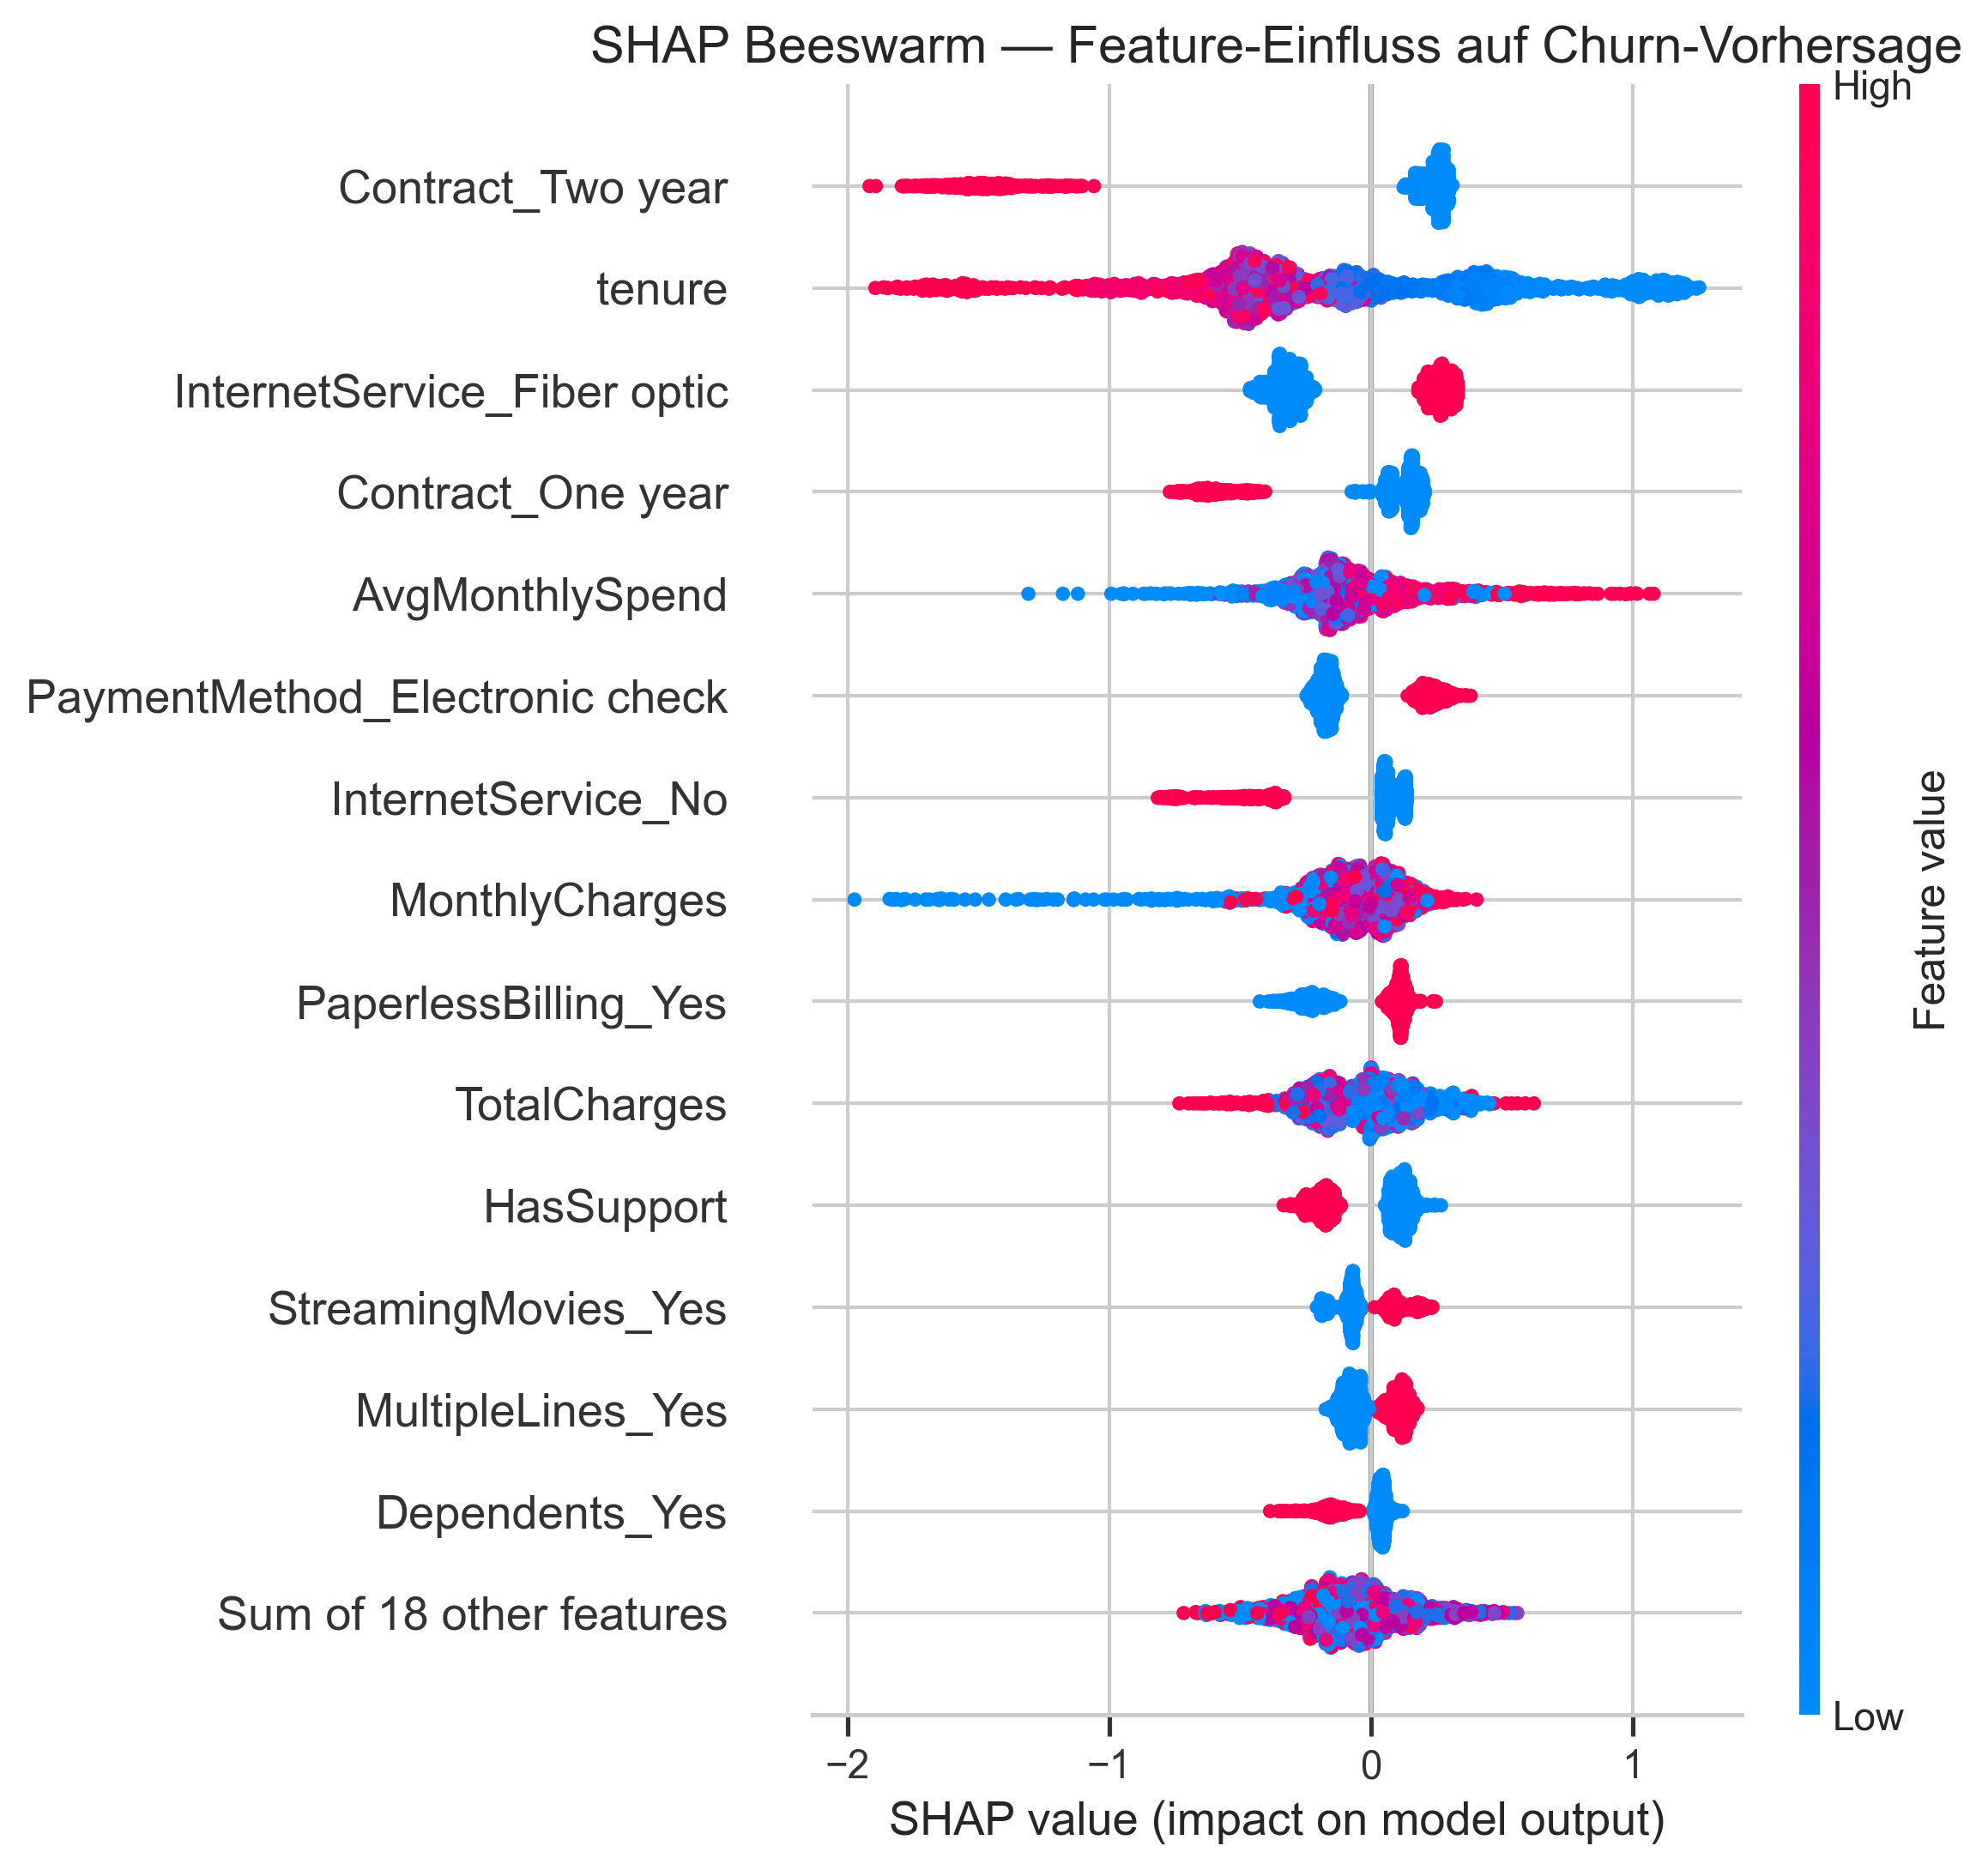

In [4]:
# Beeswarm-Plot
plot_beeswarm(shap_values, max_display=15, filename="22_shap_beeswarm.png")
plt.show()

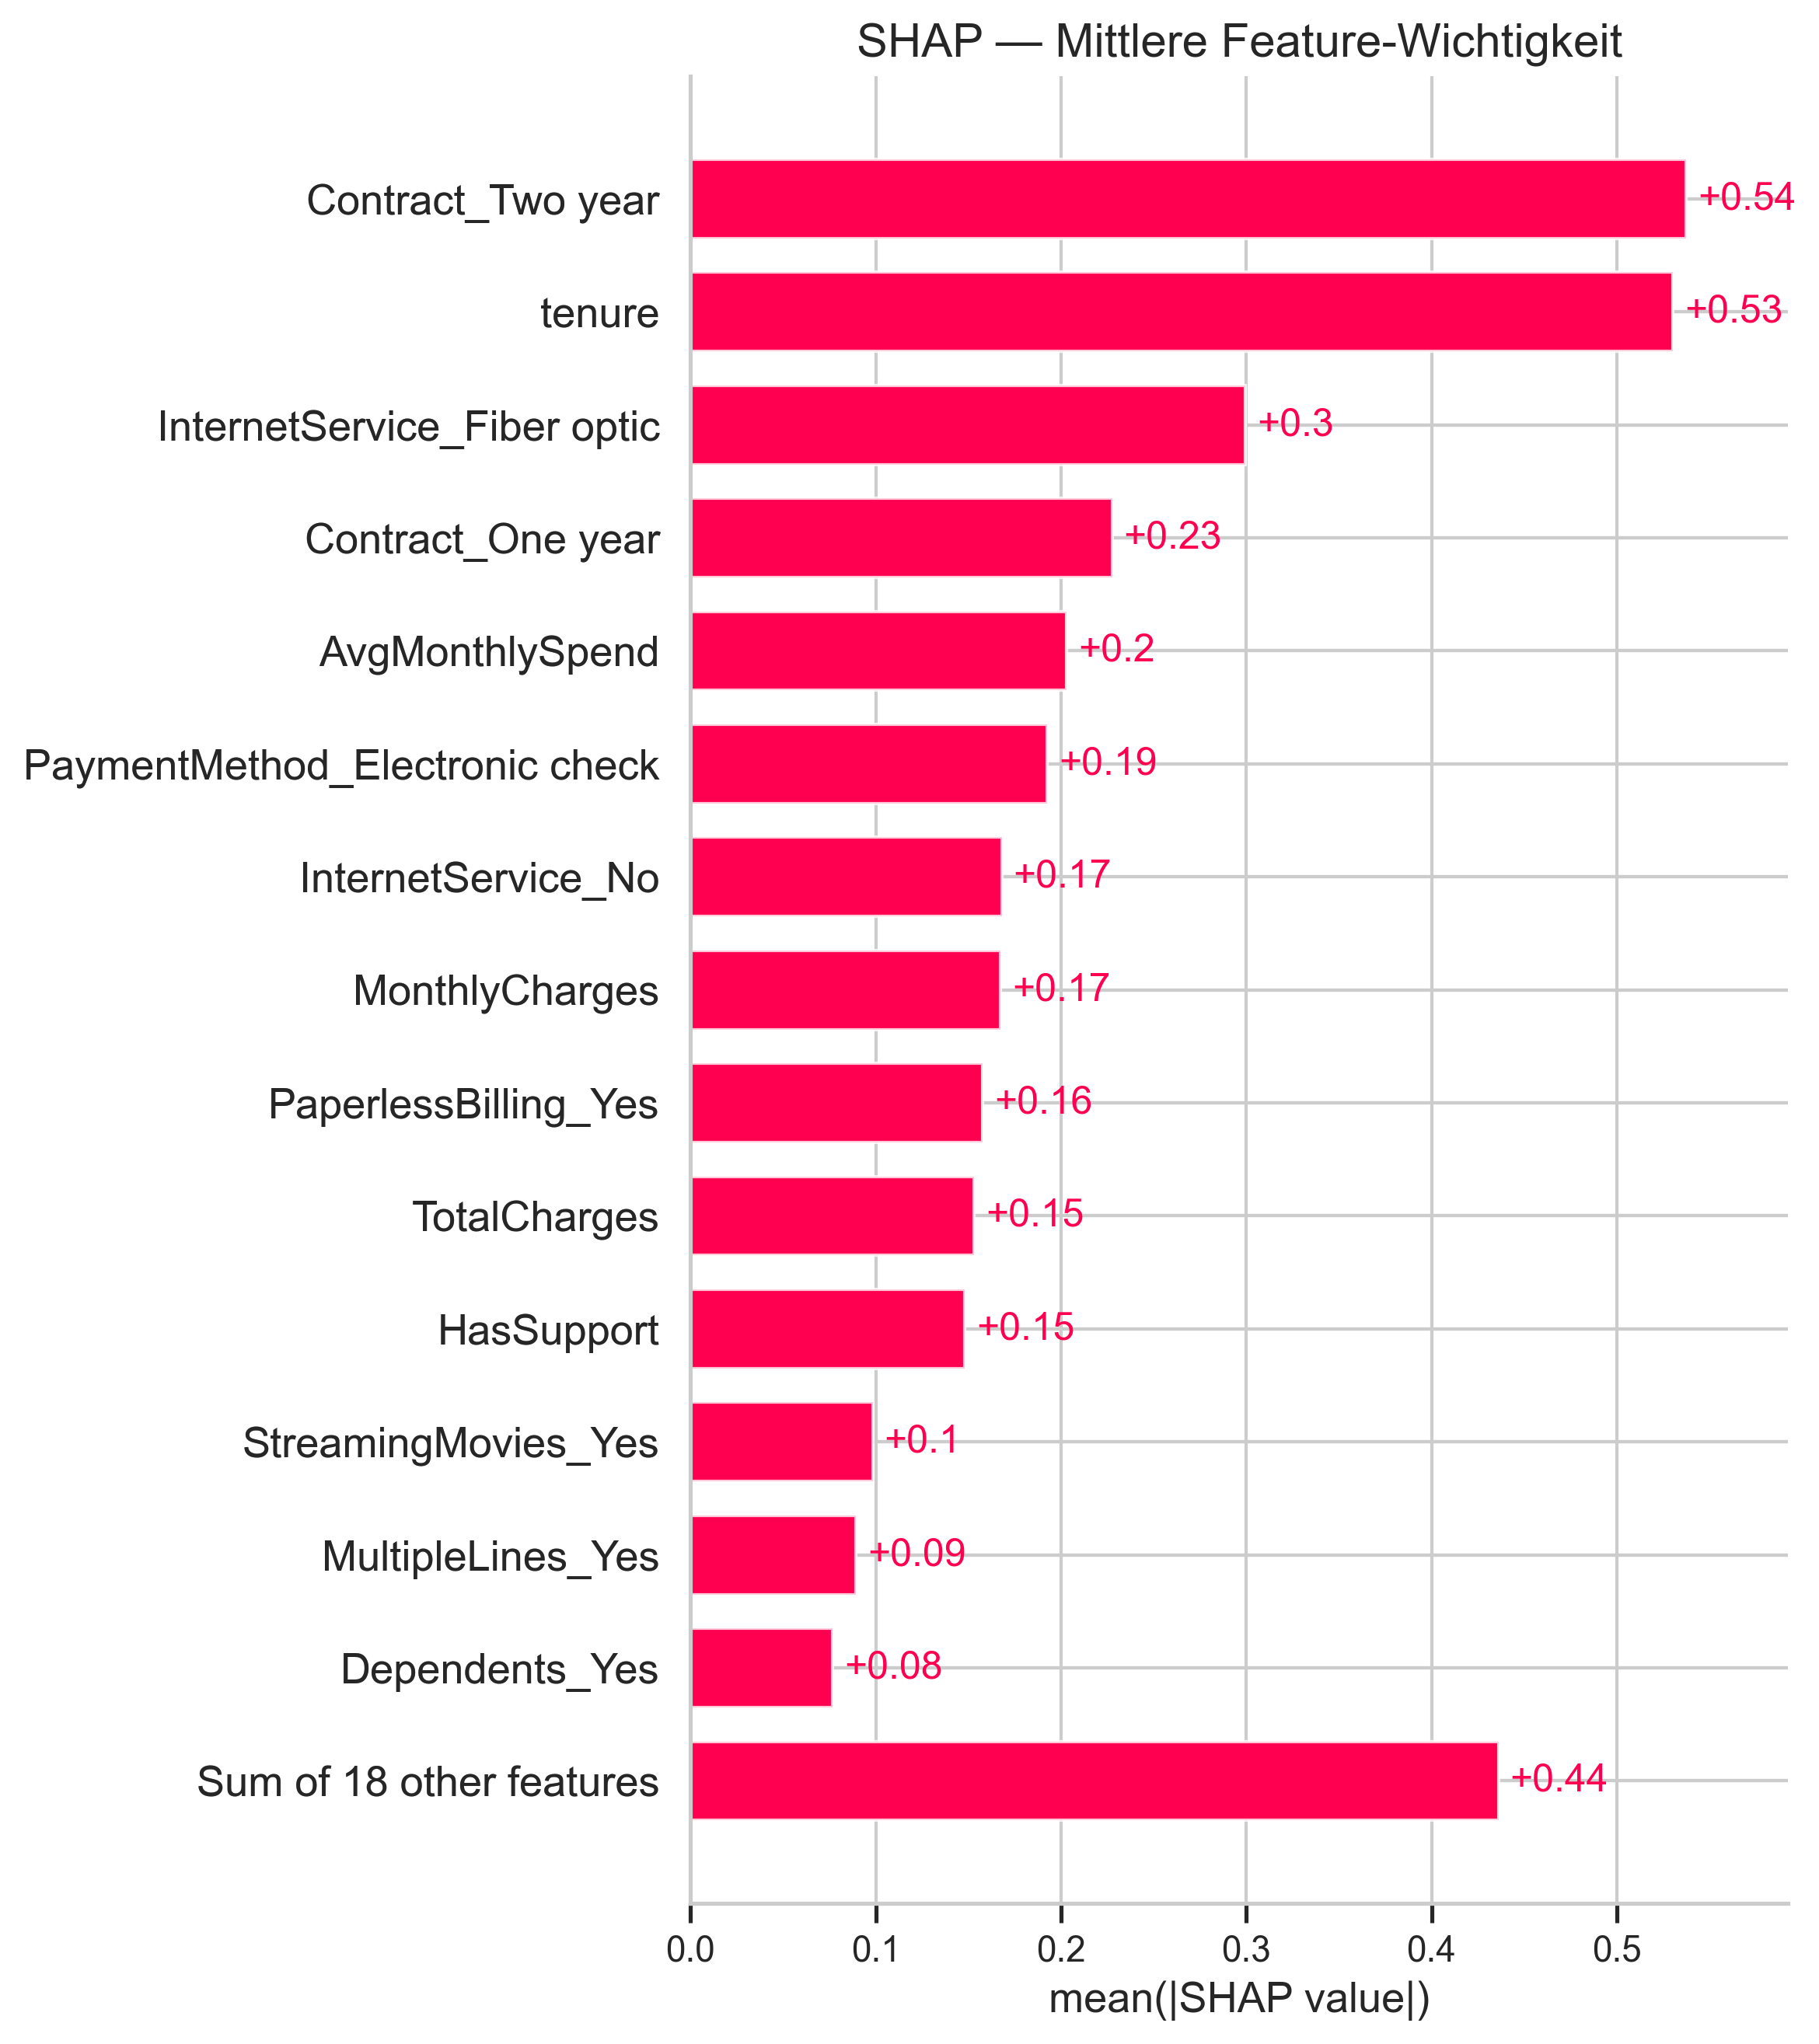

In [5]:
# Bar-Plot: Mittlere absolute SHAP-Werte
plot_shap_bar(shap_values, max_display=15, filename="23_shap_bar.png")
plt.show()

In [6]:
# Vergleich: SHAP vs. XGBoost Feature Importance
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "shap_mean_abs": np.abs(shap_values.values).mean(axis=0),
}).sort_values("shap_mean_abs", ascending=False).head(15)

xgb_importance = pd.DataFrame({
    "feature": X_test.columns,
    "xgb_importance": xgb_model.feature_importances_,
}).sort_values("xgb_importance", ascending=False).head(15)

print("Top-15 SHAP vs. XGBoost Feature Importance:")
print(f"{'Rang':<5} {'SHAP':<35} {'XGBoost Importance':<35}")
print("-" * 75)
for i in range(15):
    shap_feat = shap_importance.iloc[i]["feature"]
    xgb_feat = xgb_importance.iloc[i]["feature"]
    print(f"{i+1:<5} {shap_feat:<35} {xgb_feat:<35}")

Top-15 SHAP vs. XGBoost Feature Importance:
Rang  SHAP                                XGBoost Importance                 
---------------------------------------------------------------------------
1     Contract_Two year                   Contract_Two year                  
2     tenure                              InternetService_Fiber optic        
3     InternetService_Fiber optic         Contract_One year                  
4     Contract_One year                   InternetService_No                 
5     AvgMonthlySpend                     PaymentMethod_Electronic check     
6     PaymentMethod_Electronic check      StreamingMovies_Yes                
7     InternetService_No                  tenure                             
8     MonthlyCharges                      HasSupport                         
9     PaperlessBilling_Yes                PaperlessBilling_Yes               
10    TotalCharges                        HasStreaming                       
11    HasSupport      

---
## 9.3 Lokale Erklaerung

**Frau Mueller (High-Risk):** Senior, Monatsvertrag, Fiber optic, kein TechSupport, tenure 3, Electronic check  
**Herr Weber (Low-Risk):** Partner, 2-Jahresvertrag, DSL, TechSupport, tenure 48, Bank transfer

In [7]:
# Passende Kunden im Testset finden
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# High-Risk: Hoechster Score
idx_high = np.argmax(y_prob)
print(f"High-Risk Kunde (Index {idx_high}): Score = {y_prob[idx_high]:.3f}")

# Low-Risk: Niedrigster Score
idx_low = np.argmin(y_prob)
print(f"Low-Risk Kunde (Index {idx_low}): Score = {y_prob[idx_low]:.3f}")

High-Risk Kunde (Index 445): Score = 0.973
Low-Risk Kunde (Index 1856): Score = 0.003


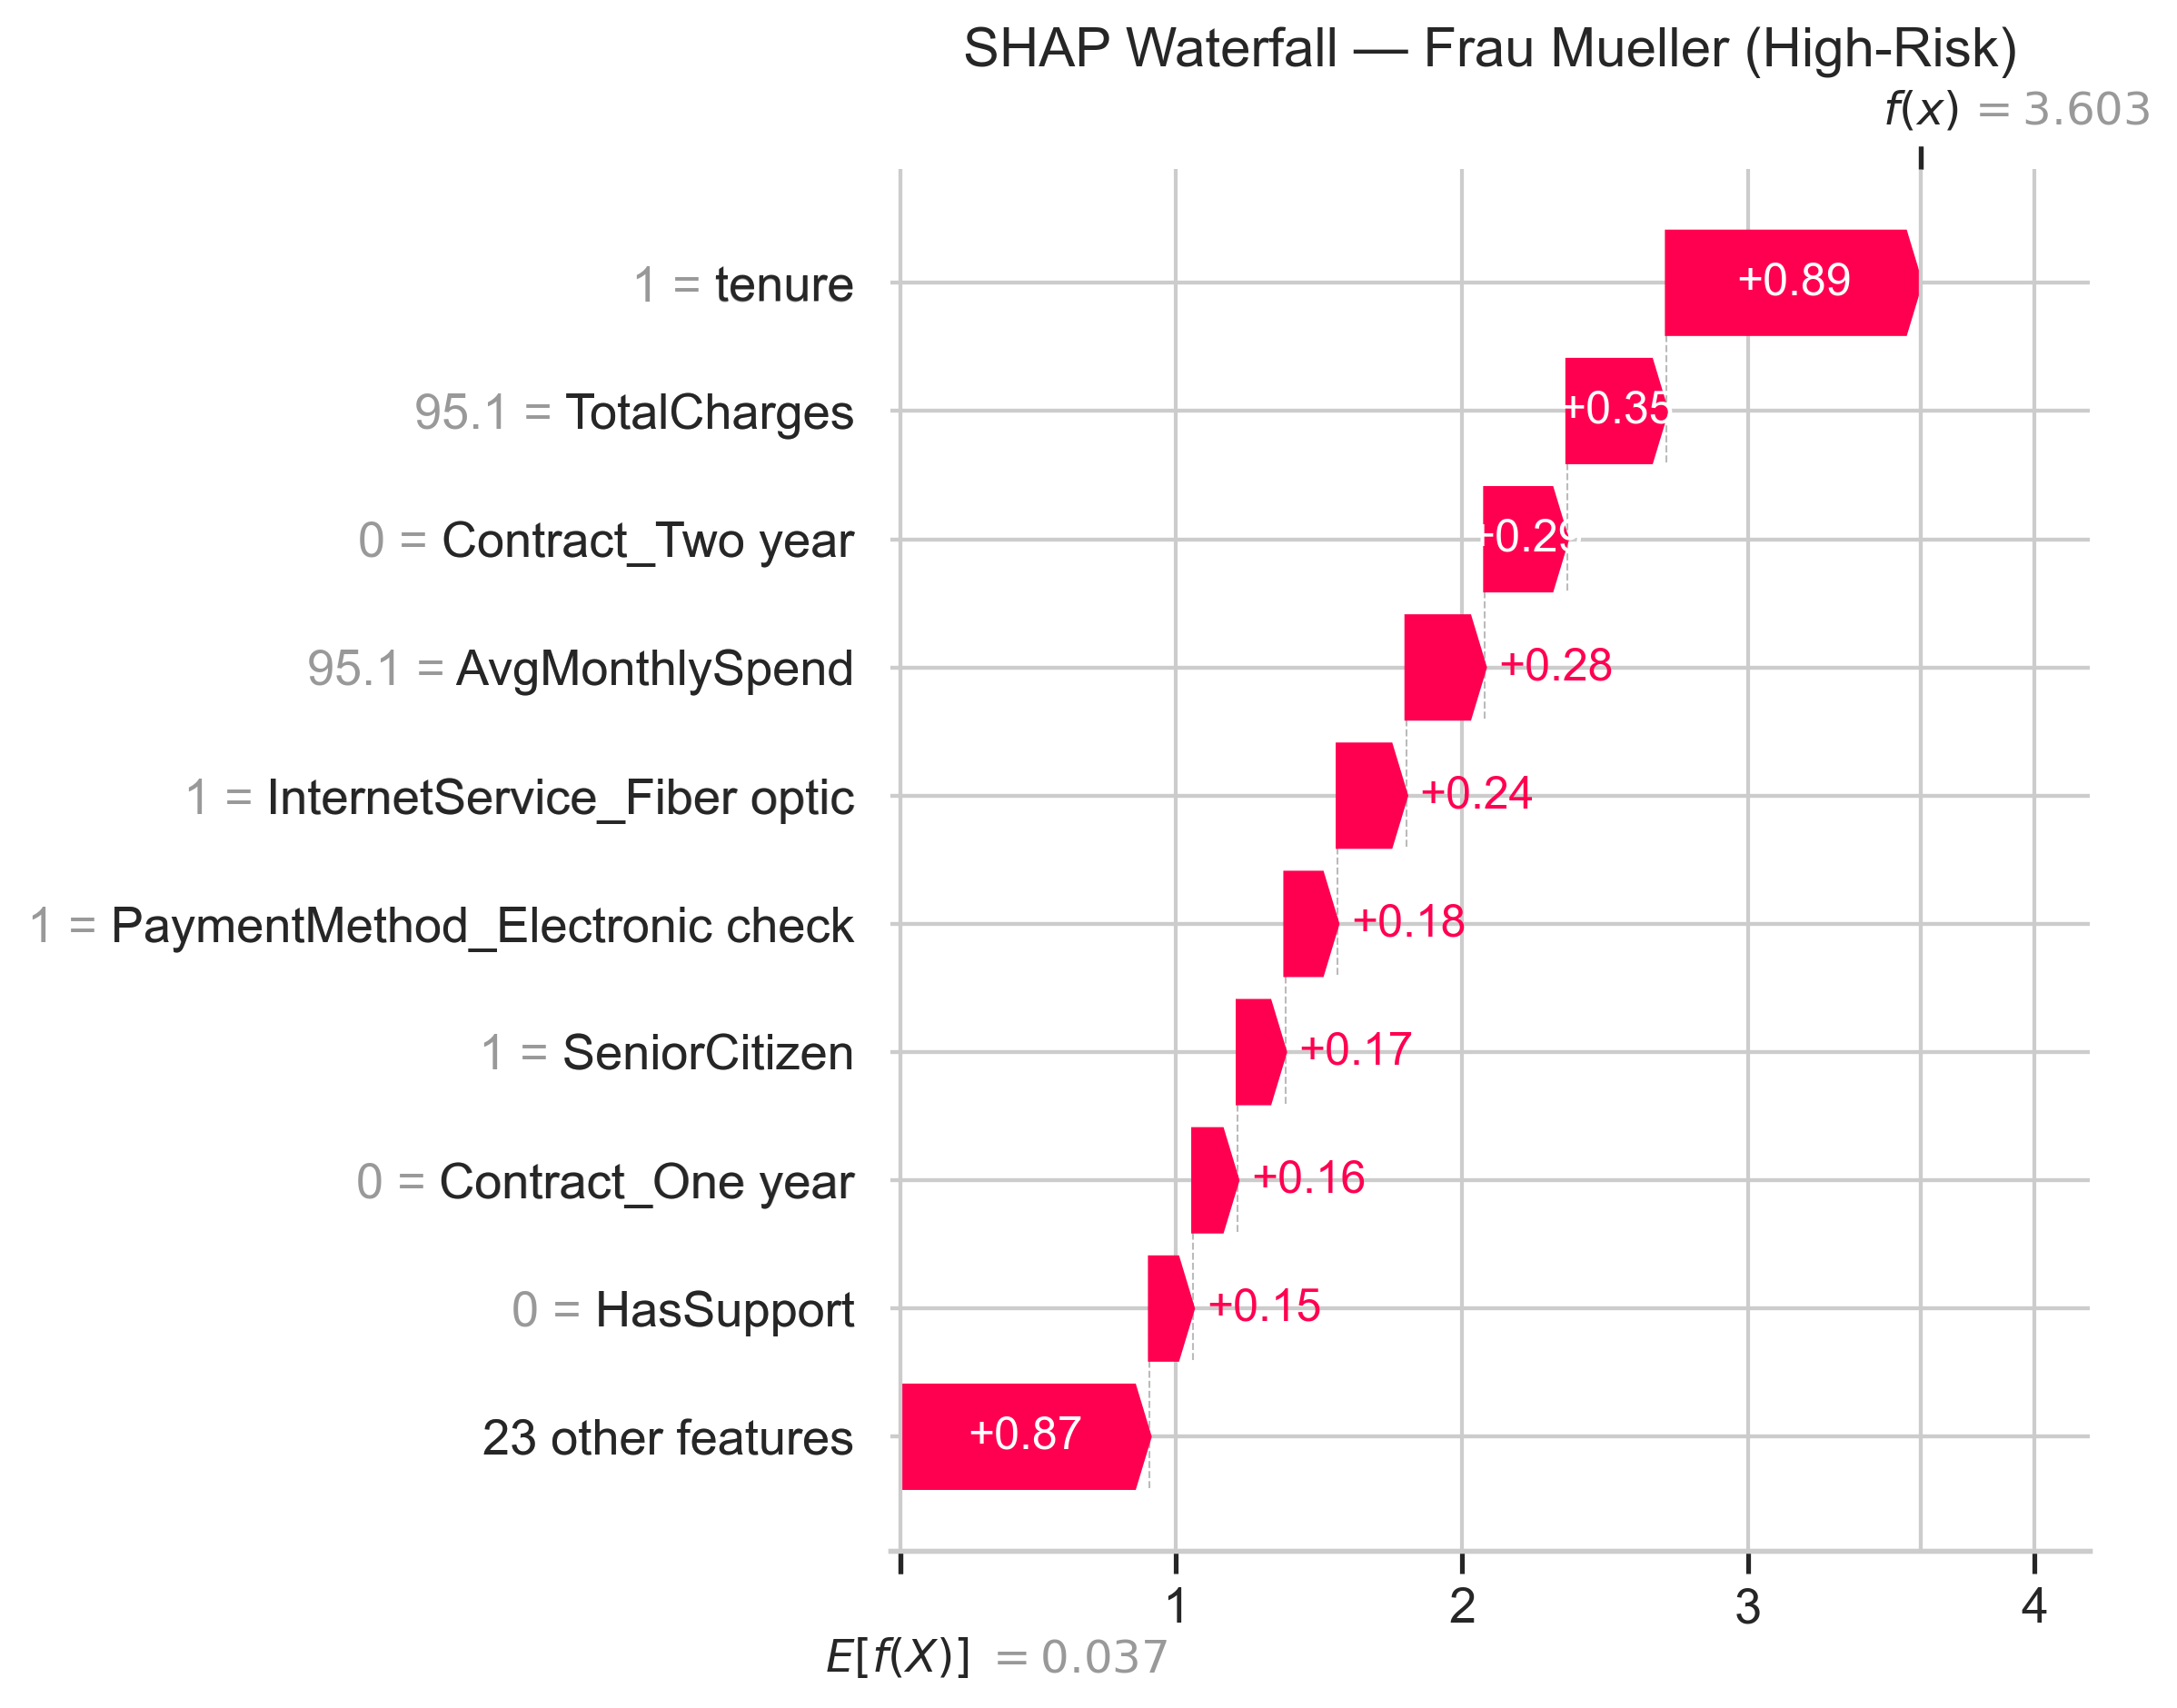

In [8]:
# Waterfall: High-Risk-Kunde (Frau Mueller)
plot_waterfall(shap_values, idx_high, customer_name="Frau Mueller (High-Risk)", filename="24_shap_waterfall_high_risk.png")
plt.show()

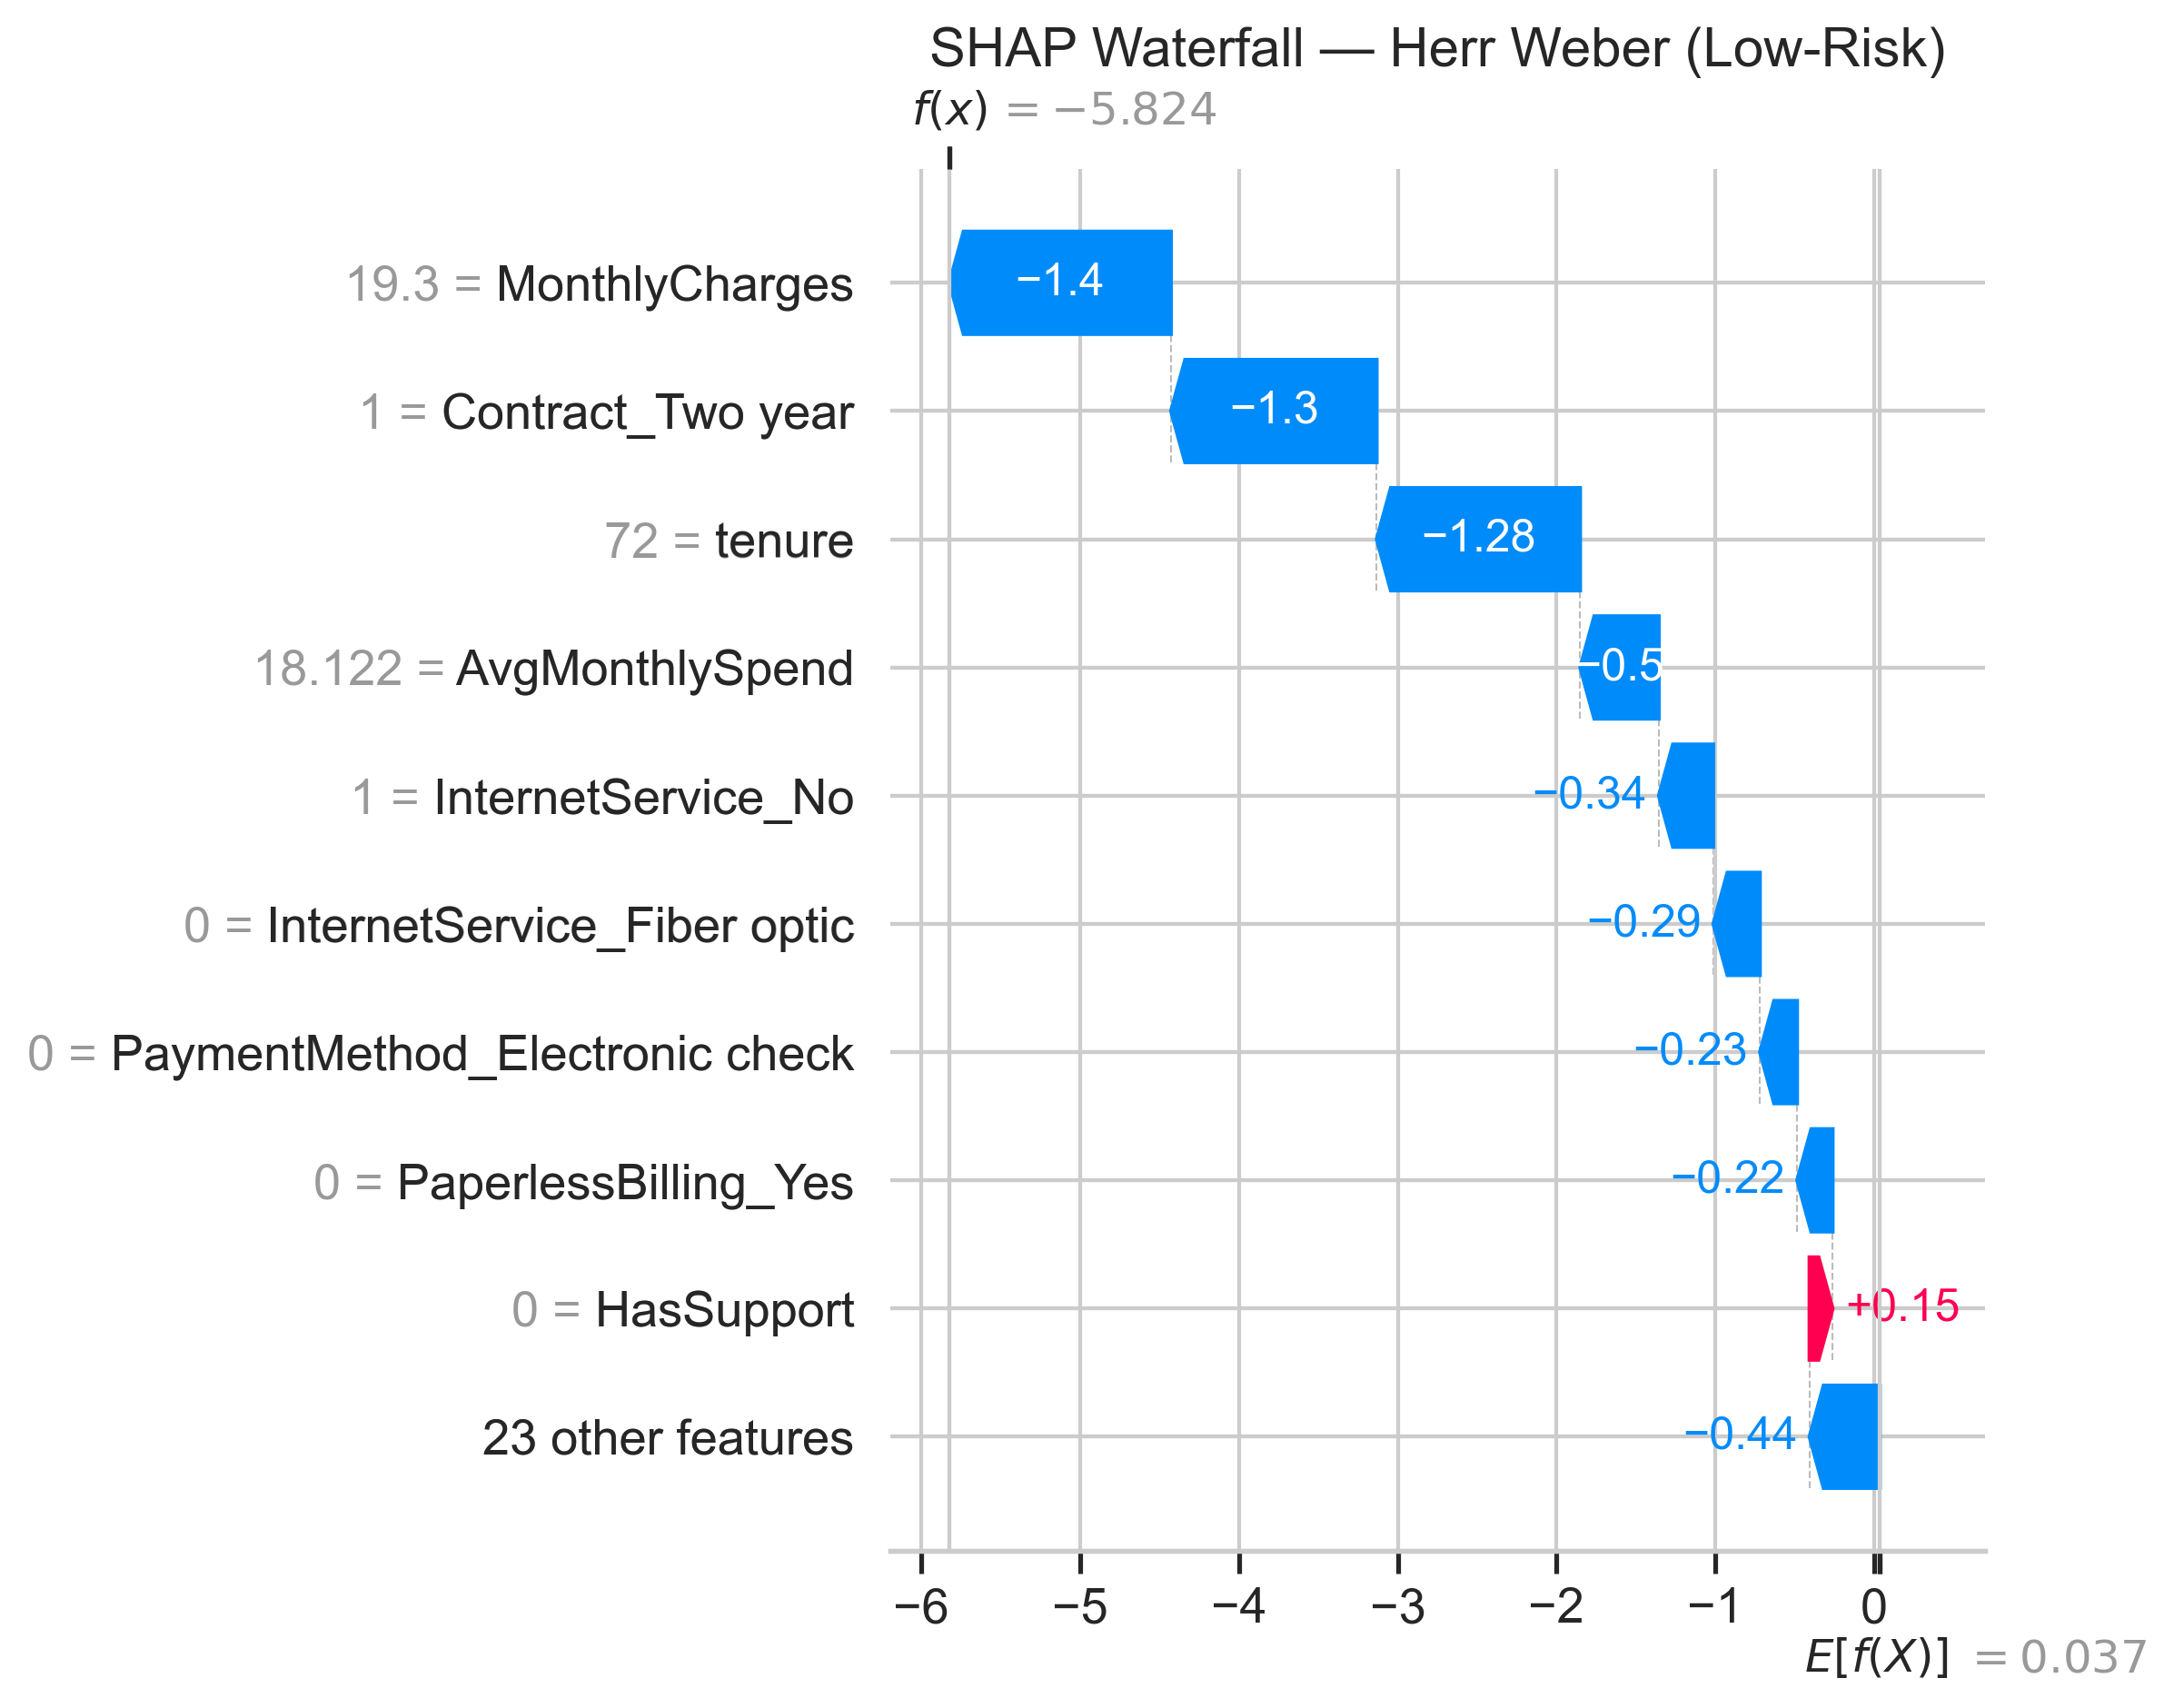

In [9]:
# Waterfall: Low-Risk-Kunde (Herr Weber)
plot_waterfall(shap_values, idx_low, customer_name="Herr Weber (Low-Risk)", filename="25_shap_waterfall_low_risk.png")
plt.show()

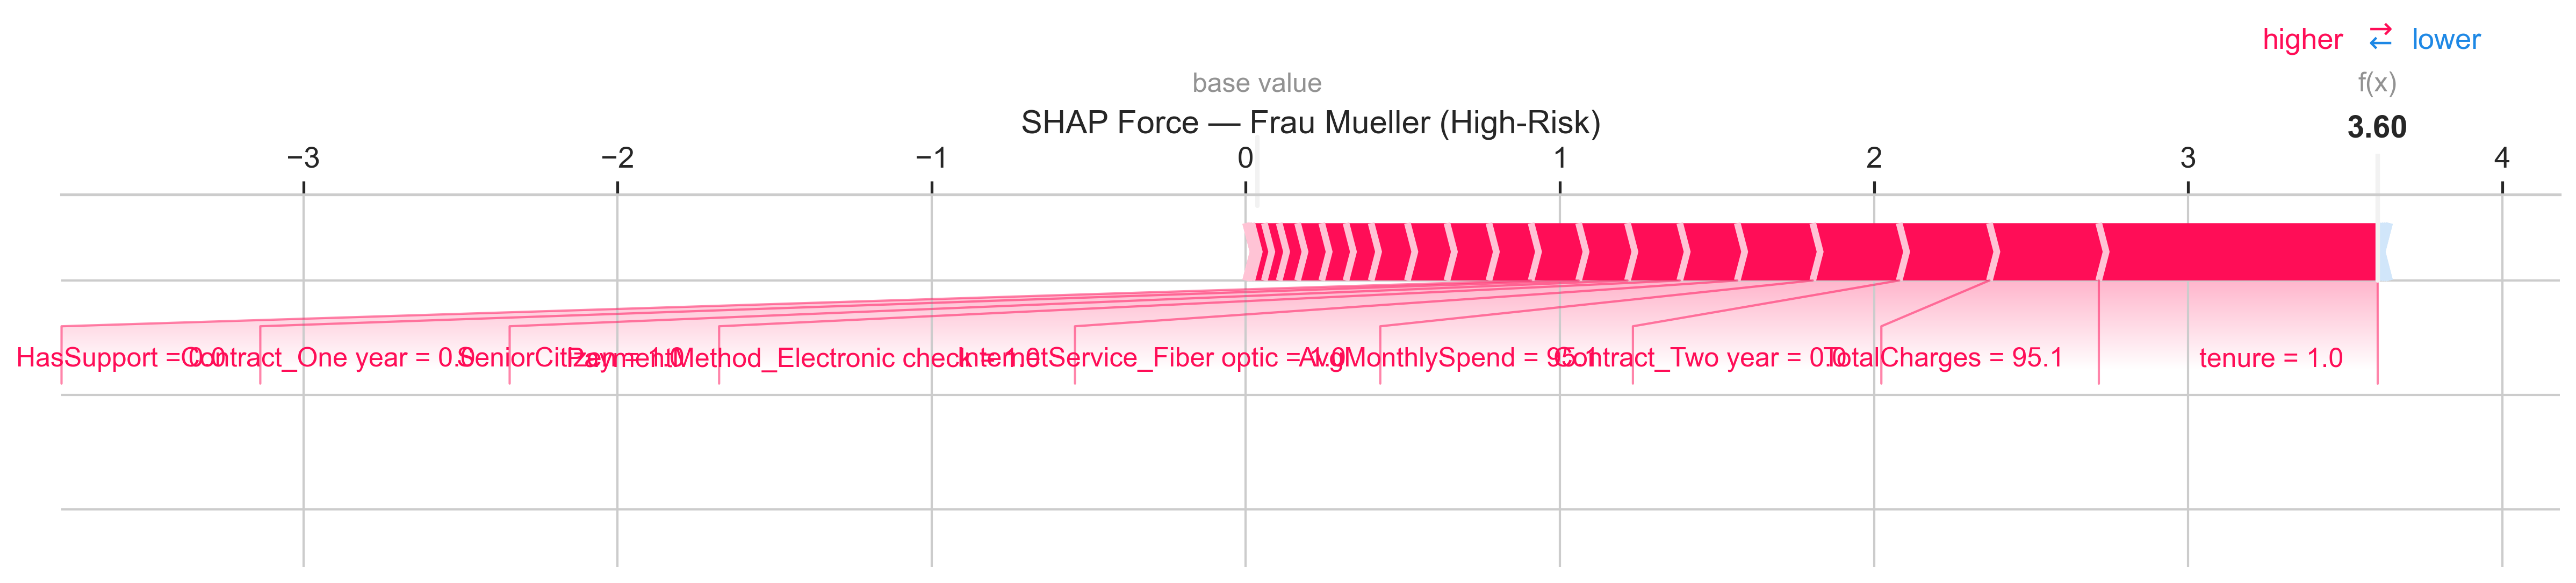

In [10]:
# Force-Plot: High-Risk
plot_force(shap_values, idx_high, customer_name="Frau Mueller (High-Risk)", filename="26_shap_force_high_risk.png")
plt.show()

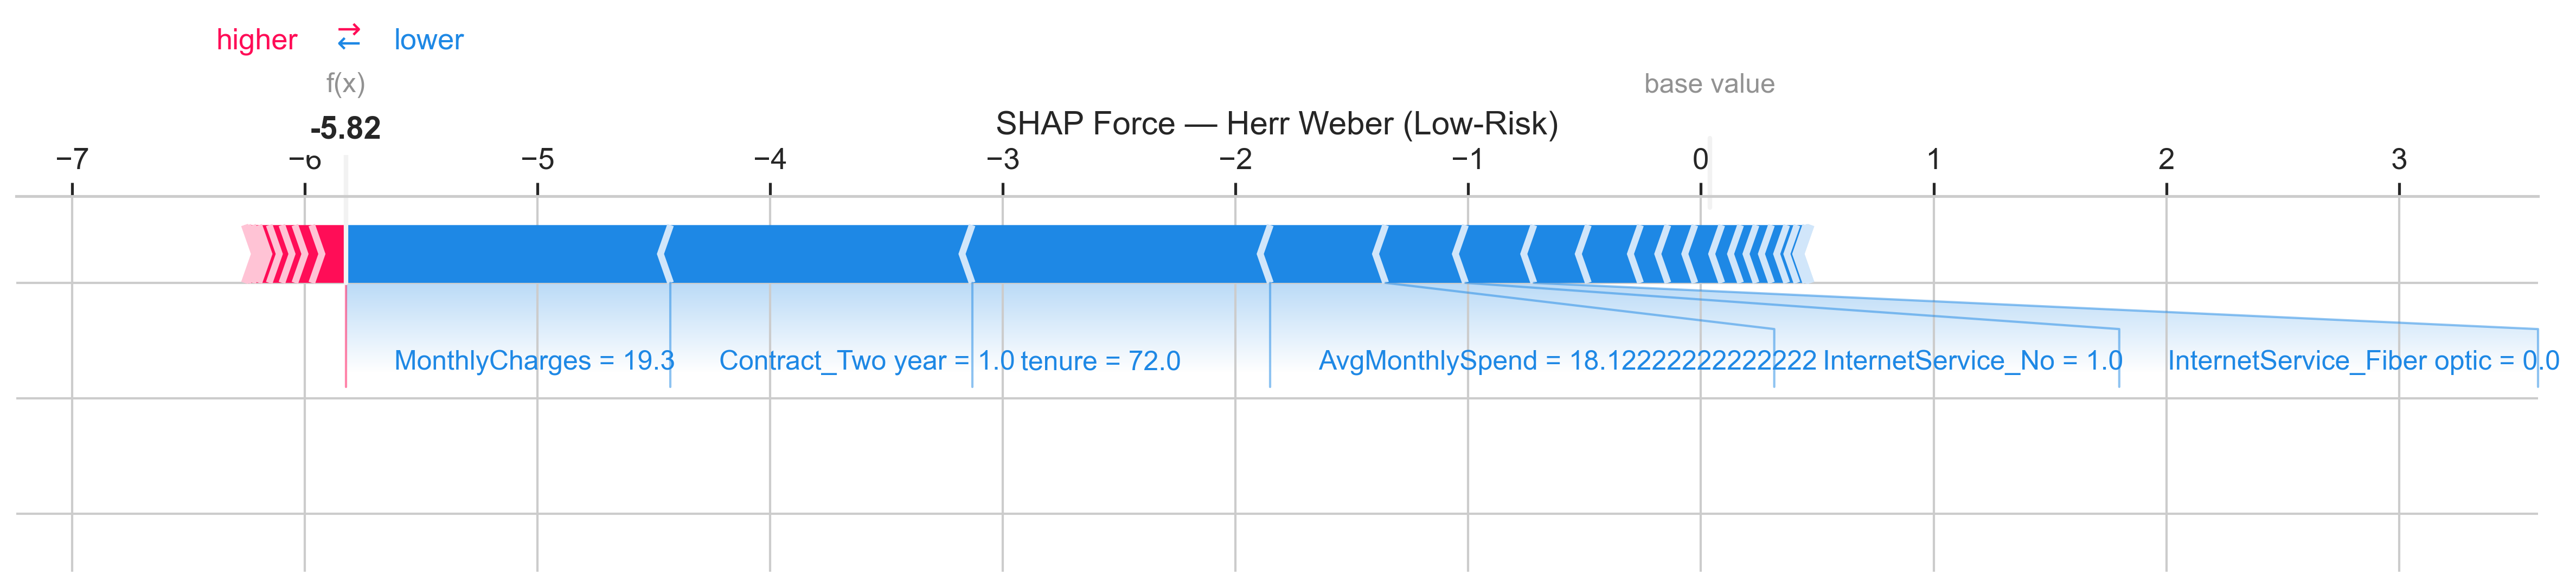

In [11]:
# Force-Plot: Low-Risk
plot_force(shap_values, idx_low, customer_name="Herr Weber (Low-Risk)", filename="27_shap_force_low_risk.png")
plt.show()

---
## 9.4 Dependency-Plots

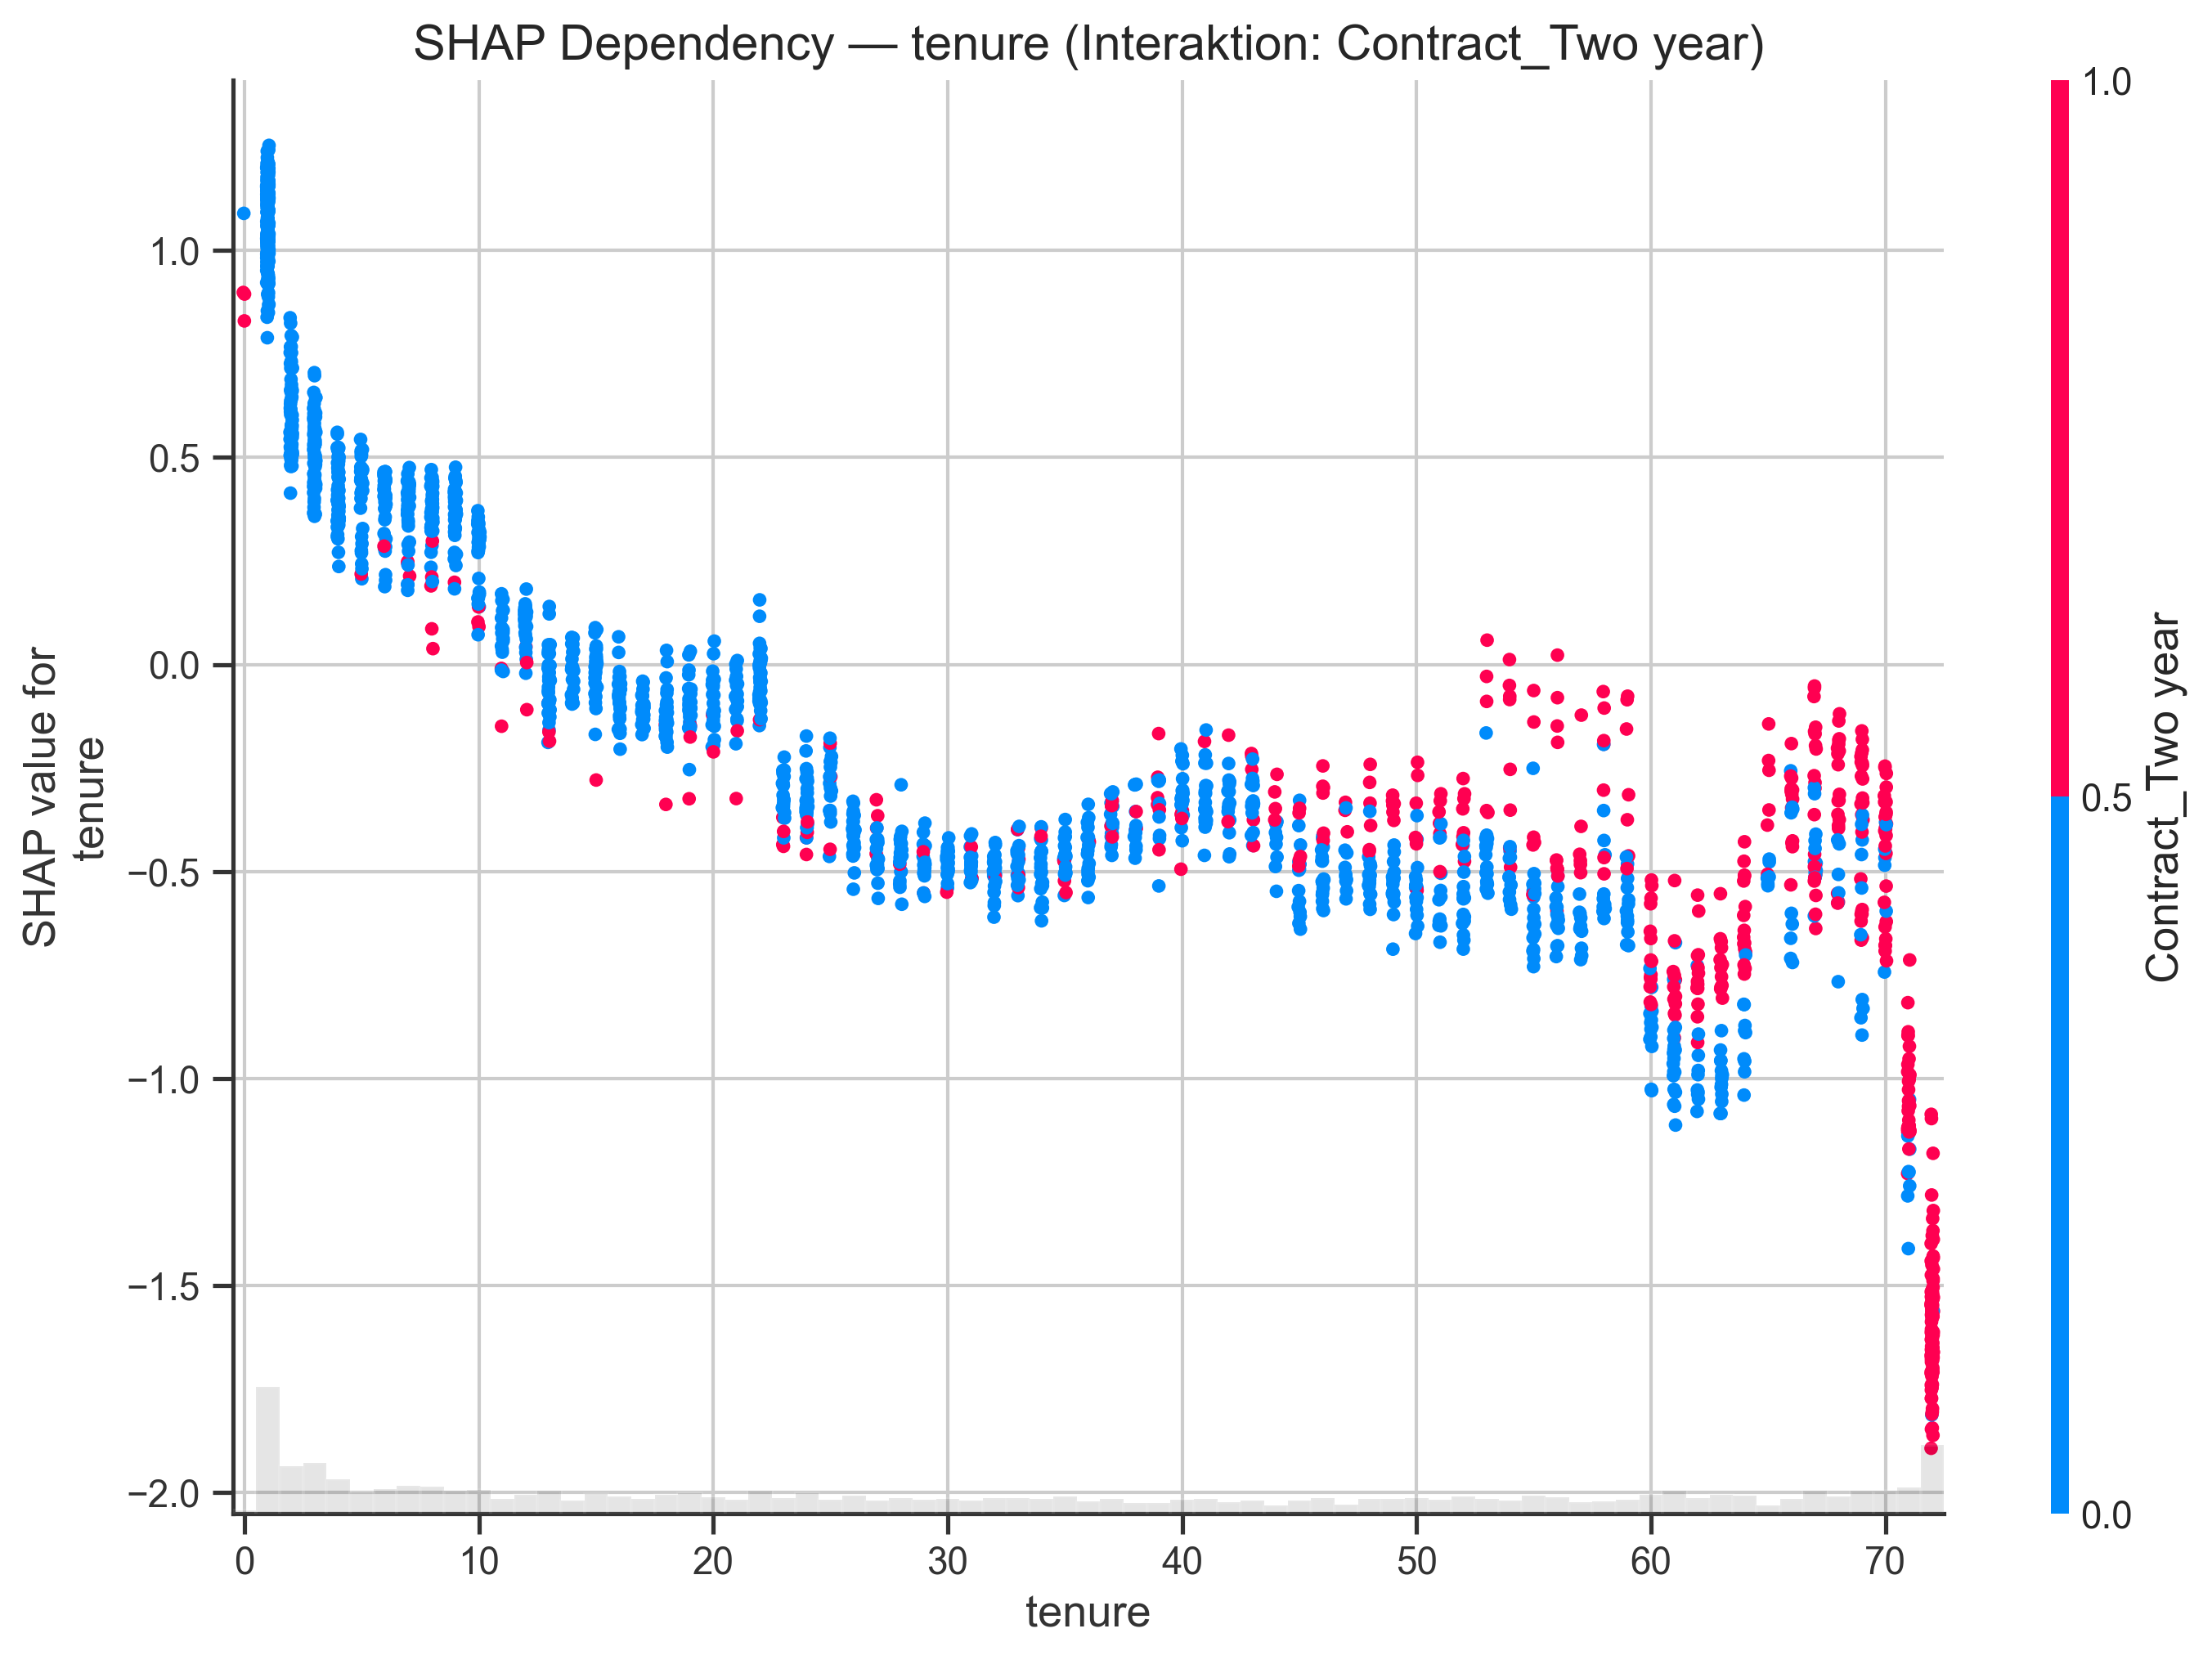

In [12]:
# Contract vs. tenure
plot_dependency(shap_values, "tenure", interaction_feature="Contract_Two year", filename="28_shap_dependency_tenure.png")
plt.show()

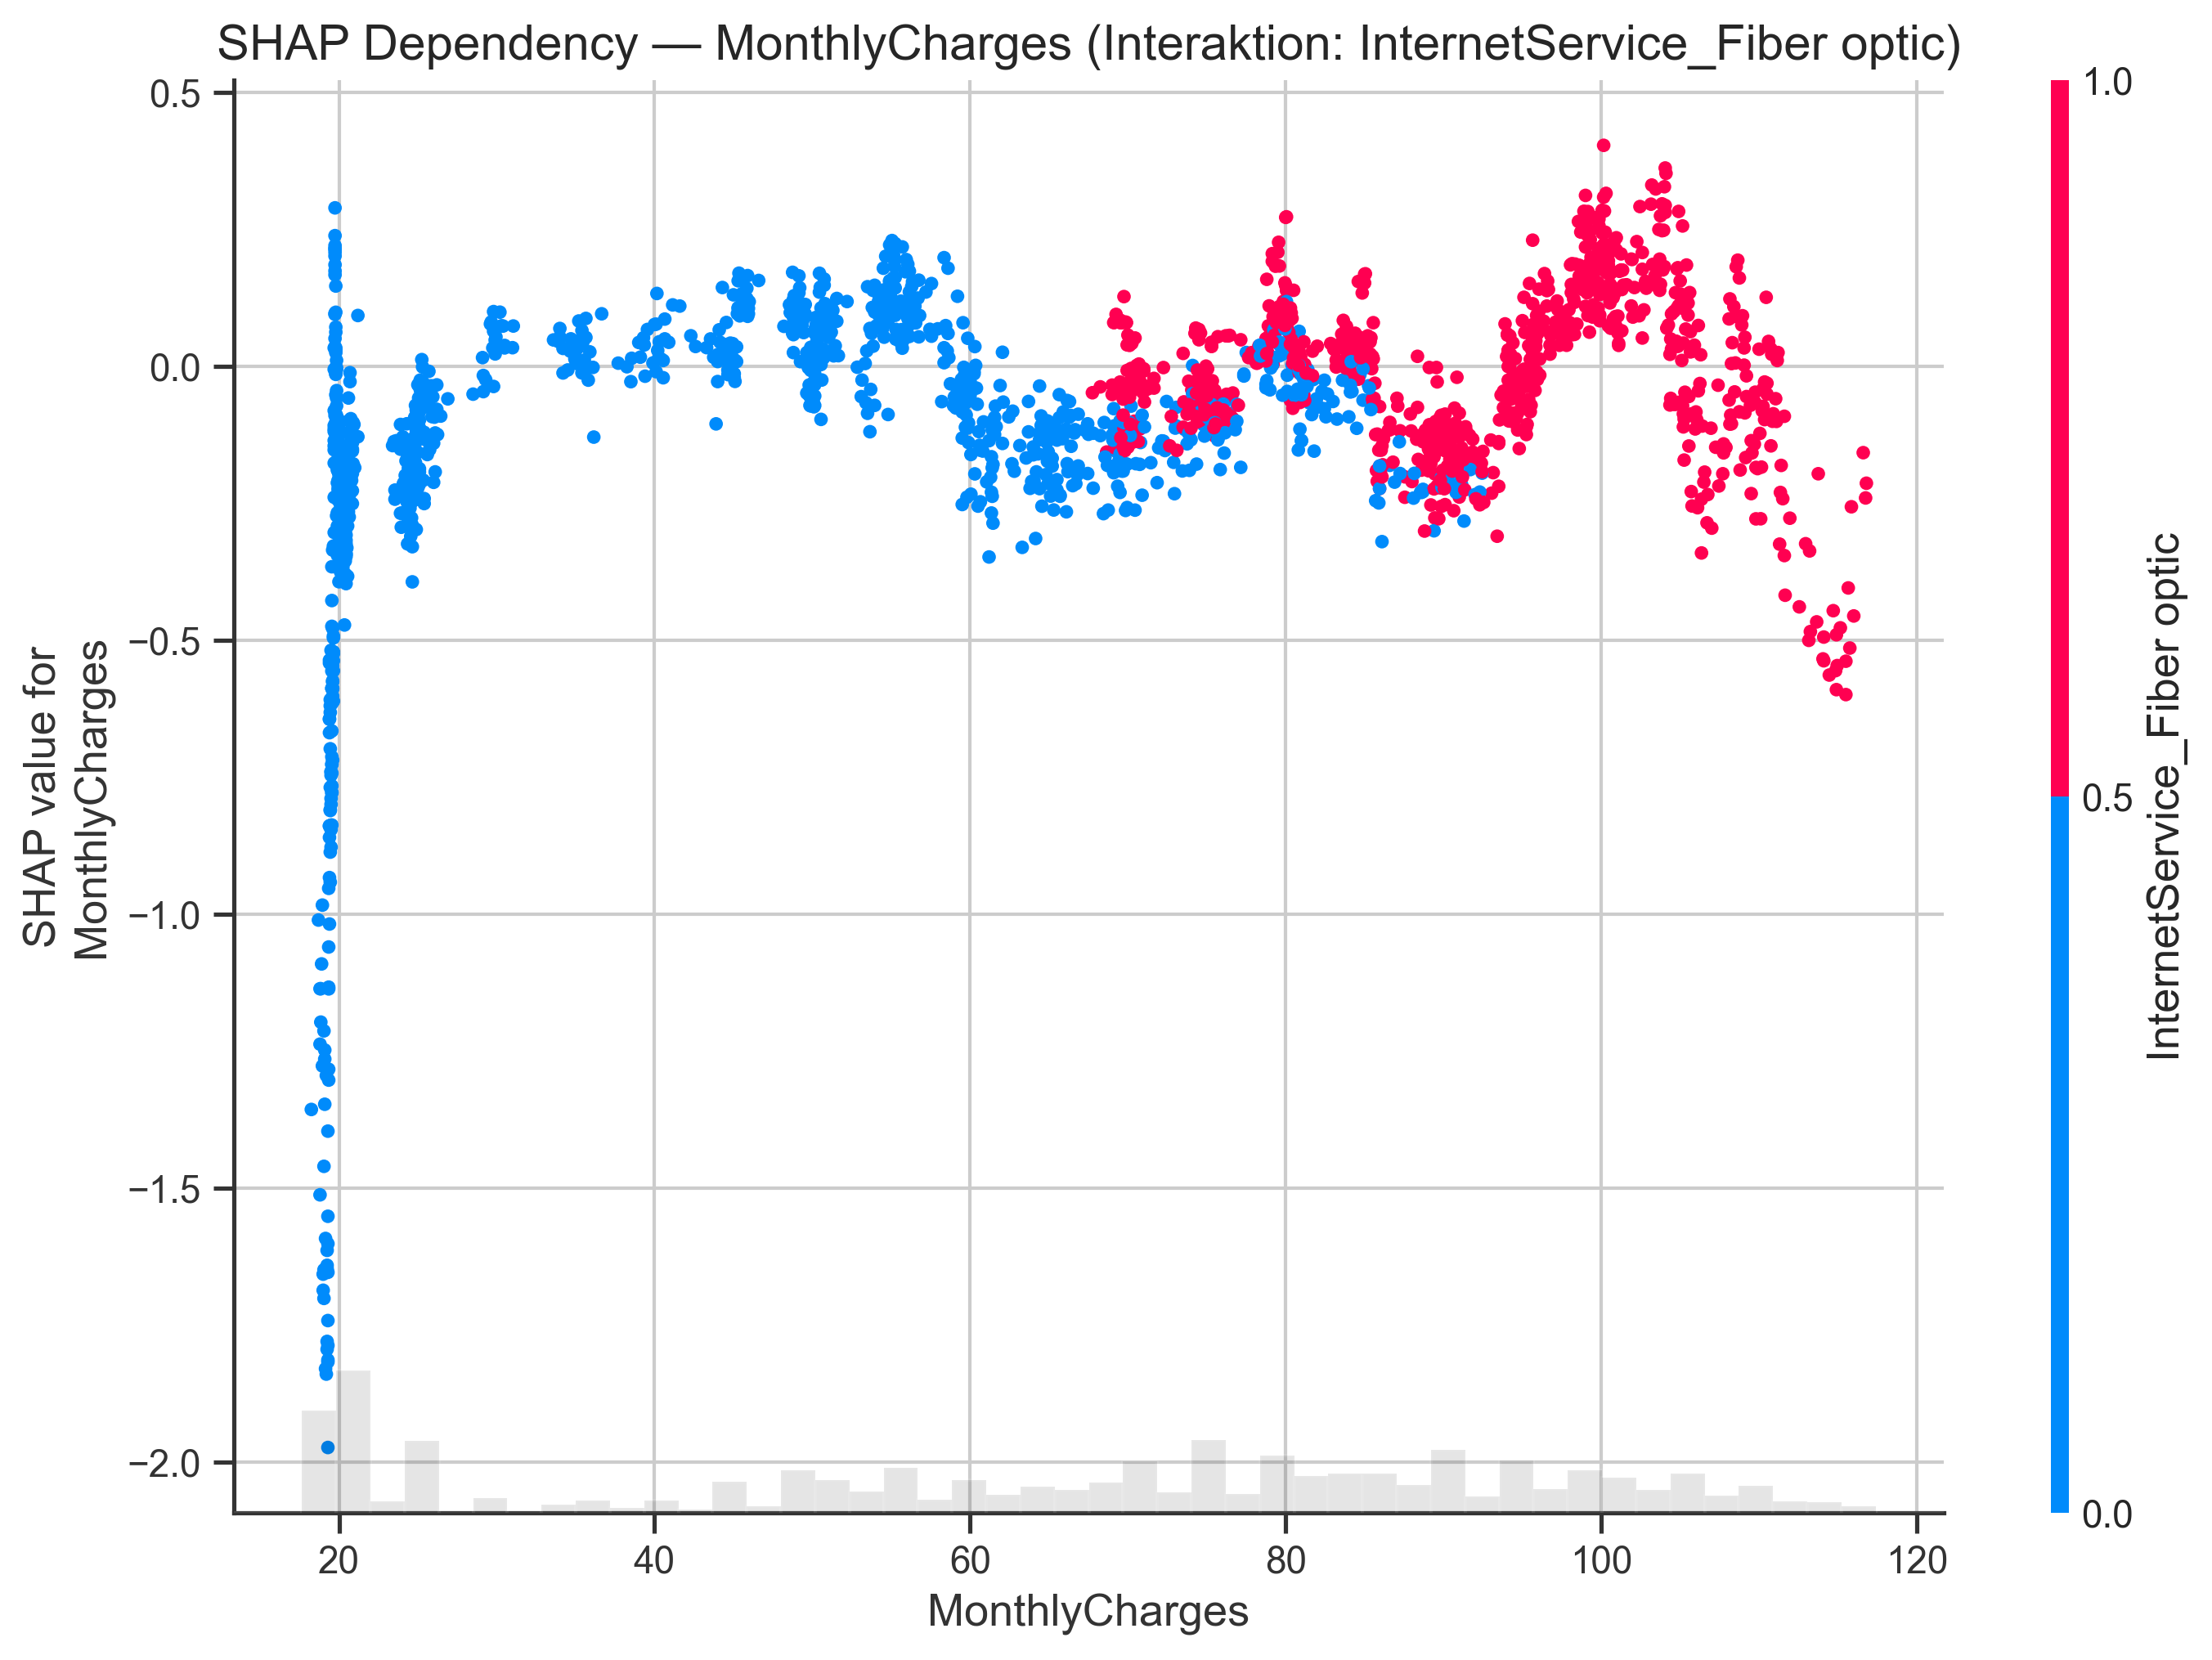

In [13]:
# MonthlyCharges vs. InternetService
plot_dependency(shap_values, "MonthlyCharges", interaction_feature="InternetService_Fiber optic", filename="29_shap_dependency_monthlycharges.png")
plt.show()

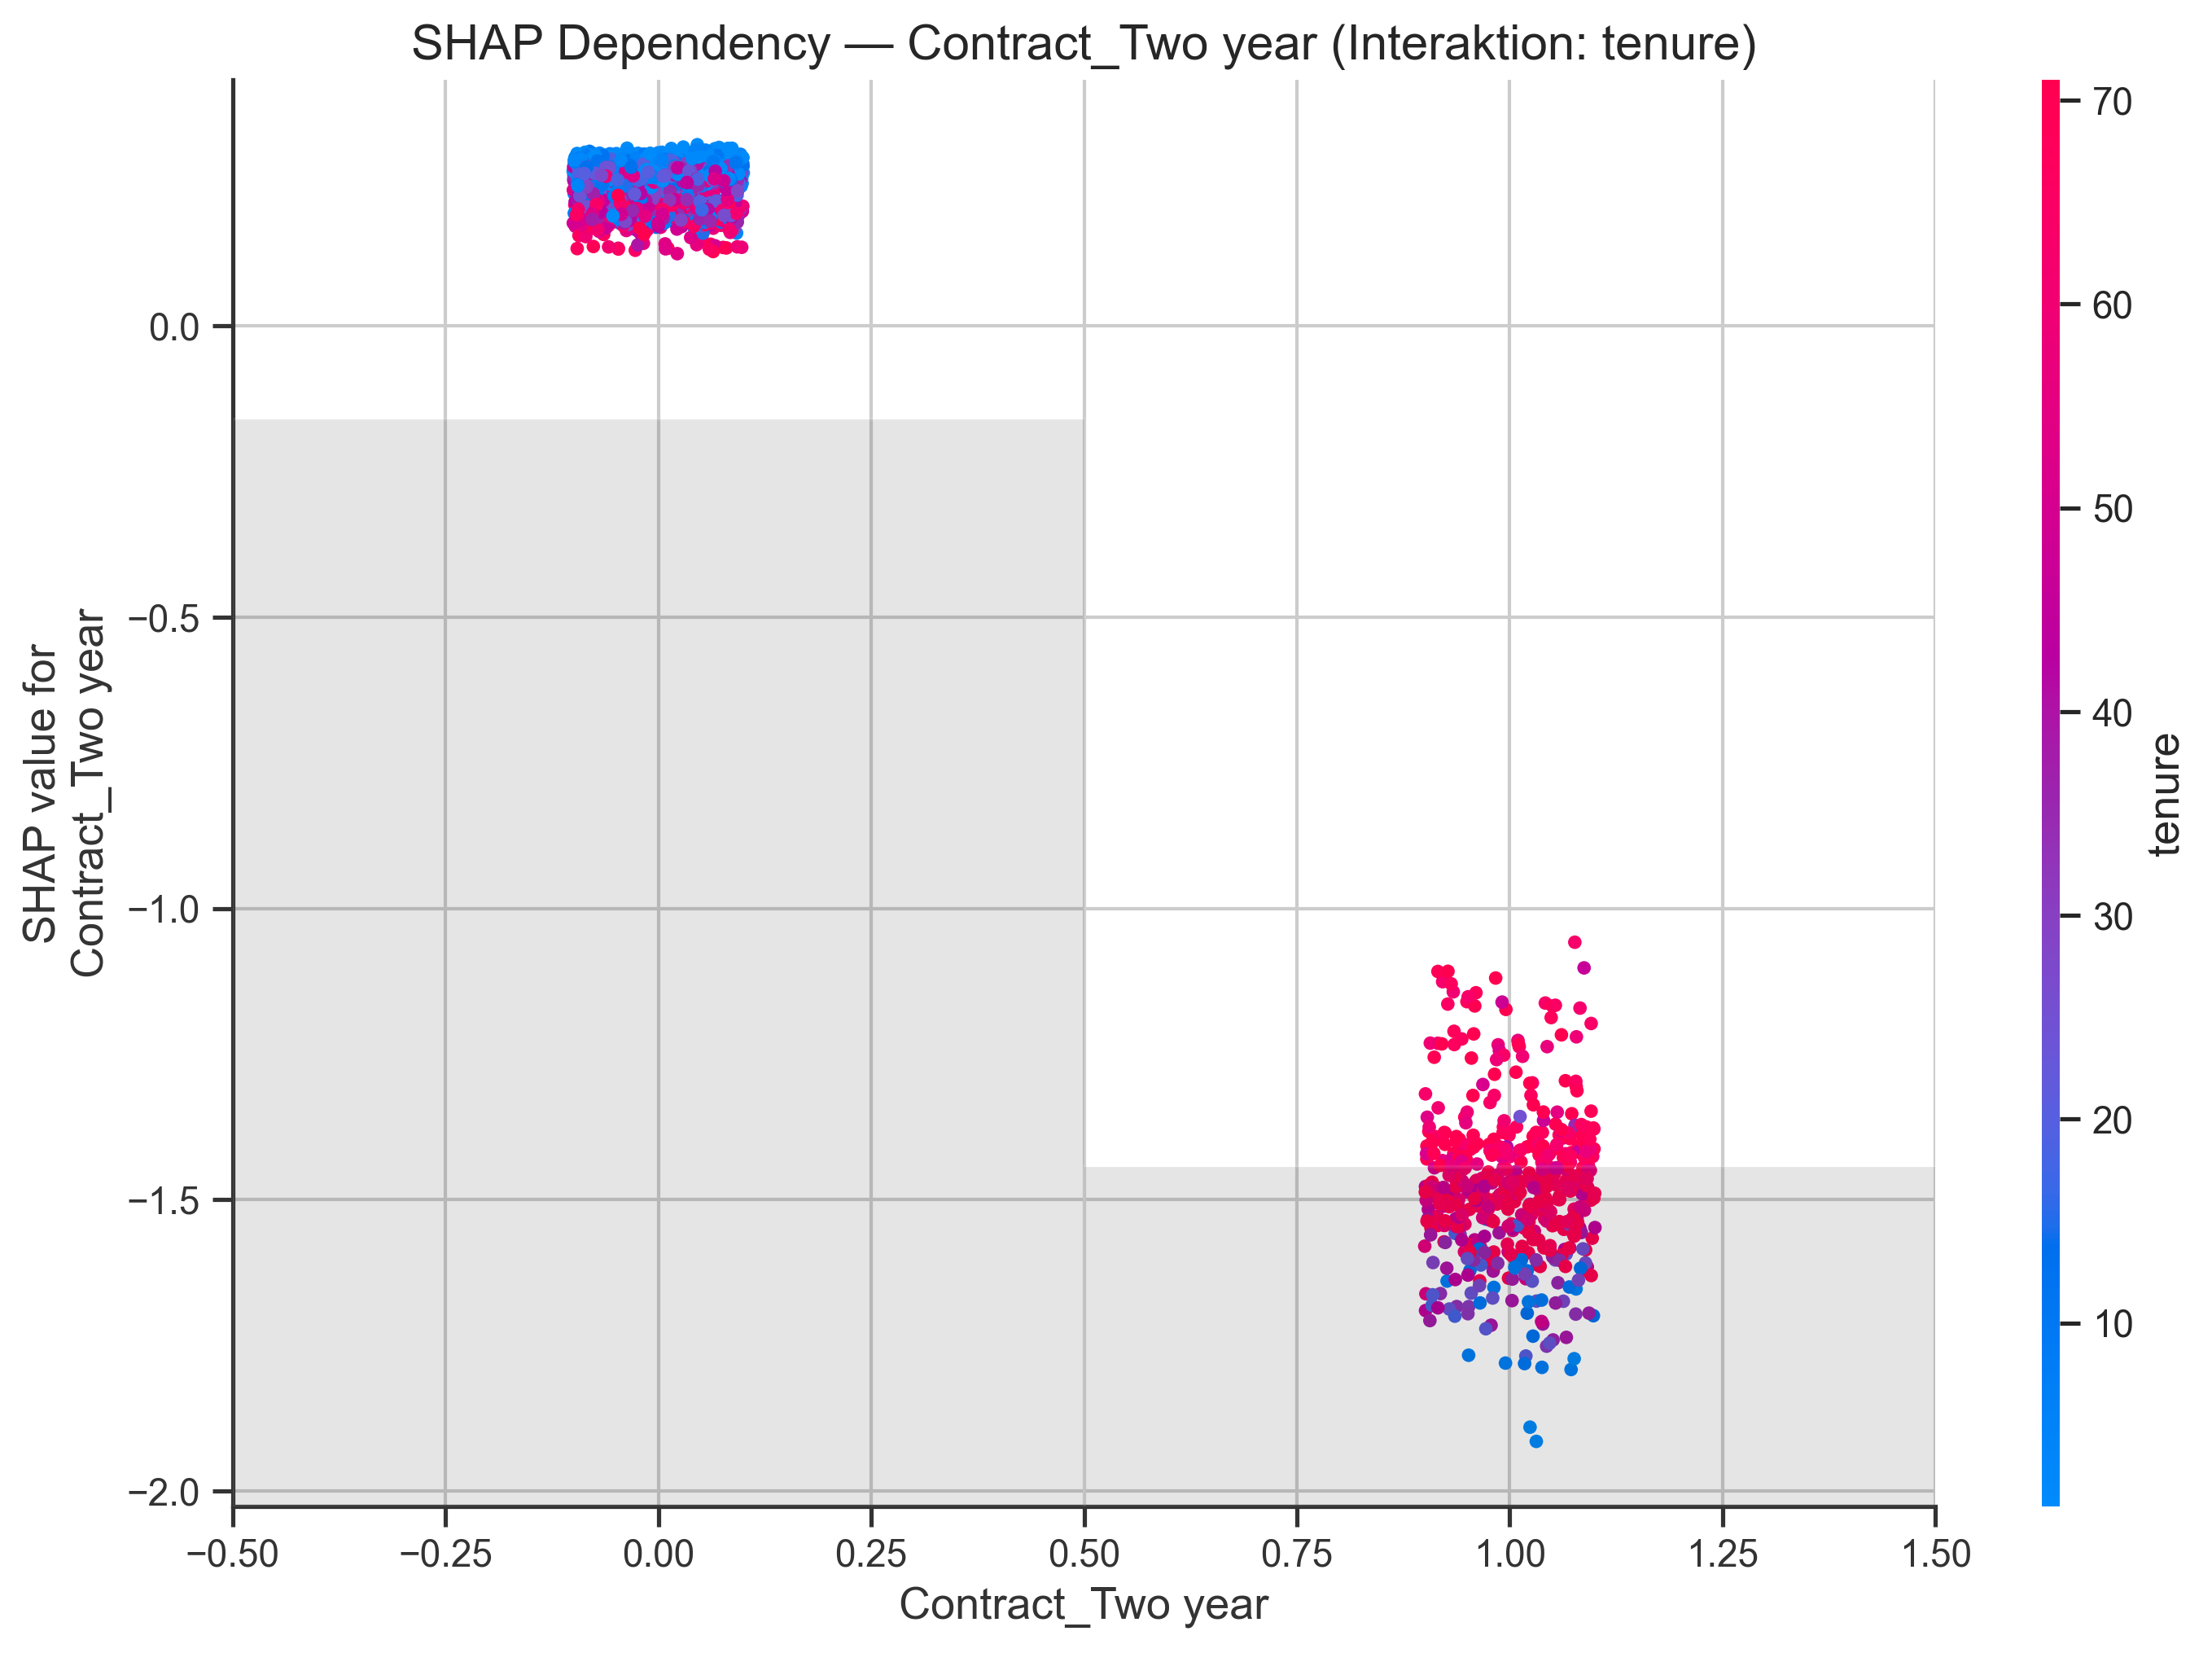

In [14]:
# Contract_Two year vs. tenure
plot_dependency(shap_values, "Contract_Two year", interaction_feature="tenure", filename="30_shap_dependency_contract.png")
plt.show()

---
## SHAP Explainer speichern

In [15]:
joblib.dump(explainer, "models/shap_explainer.pkl")
print("SHAP Explainer gespeichert.")

SHAP Explainer gespeichert.
